# Multimodal Sensory Dataset Generation

This notebook generates the eight-dimensional sensory dataset as described in Section 4.2:
- Visual (140-dim): EM spectrum 300-1000nm
- Auditory (128-dim): 1Hz-100kHz spectrogram
- Tactile (32-dim): Mechanical vibrations 5-800Hz
- Olfactory (10-dim): Ten scent categories
- Gustatory (5-dim): Five basic tastes
- Proprioceptive (30-dim): Joint angles and muscle tensions
- Vestibular (6-dim): 3-axis acceleration and angular velocity
- Interoceptive (8-dim): Internal physiological states

**Total dimensionality:** 359 per timestep
**Temporal structure:** 60 seconds at 1Hz = 60 timesteps
**Dataset size:** 5000 training + 1000 validation + 1000 test examples

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

# Project-wide style and figure sizing
import importlib
import setups.viz_styles as viz_styles

importlib.reload(viz_styles)
apply_project_style = viz_styles.apply_project_style
fw = viz_styles.fw
apply_project_style()

# Set random seed for reproducibility
np.random.seed(42)

# Create output directory
output_dir = Path('data')
output_dir.mkdir(exist_ok=True)


In [3]:
# Global colormaps / palettes — from setups/viz_styles.py
from setups.viz_styles import (
    WHITE_SKY_CMAP,
    MODEL_VISIBLE_COLORS,
    BLUE_GRAY_RAMP,
)


## 1. Define Sensory Modality Specifications

In [4]:
# Sensory modality specifications
MODALITY_SPECS = {
    'visual': {
        'dim': 140,
        'wavelengths': np.linspace(300, 1000, 140),  # nm
        'description': 'Electromagnetic spectrum 300-1000nm sampled at 5nm intervals'
    },
    'auditory': {
        'dim': 128,
        'freq_range': (1, 100000),  # Hz
        'description': 'Spectrogram FFT bins covering 1Hz-100kHz'
    },
    'tactile': {
        'dim': 32,
        'freq_range': (5, 800),  # Hz
        'description': 'Mechanical vibration frequencies 5-800Hz'
    },
    'olfactory': {
        'dim': 10,
        'categories': ['fruity', 'floral', 'musky', 'woody', 'earthy', 
                       'spicy', 'chemical', 'pungent', 'ethereal', 'minty'],
        'description': 'Ten olfactory categories'
    },
    'gustatory': {
        'dim': 5,
        'categories': ['sweet', 'sour', 'salty', 'bitter', 'umami'],
        'description': 'Five basic taste receptors'
    },
    'proprioceptive': {
        'dim': 30,
        'components': {'joint_angles': 20, 'muscle_tensions': 10},
        'description': '20 joint angles + 10 muscle tension sensors'
    },
    'vestibular': {
        'dim': 6,
        'components': {'linear_accel': 3, 'angular_velocity': 3},
        'description': '3-axis linear acceleration + 3-axis angular velocity'
    },
    'interoceptive': {
        'dim': 8,
        'signals': ['heart_rate', 'respiration', 'skin_conductance', 'temperature',
                    'hunger', 'thirst', 'fatigue', 'pain'],
        'description': 'Eight internal physiological signals'
    }
}

# Total dimensionality
TOTAL_DIM = sum(spec['dim'] for spec in MODALITY_SPECS.values())
print(f"Total dimensionality per timestep: {TOTAL_DIM}")

# Temporal parameters
DURATION_SEC = 60
SAMPLING_RATE = 1  # Hz
N_TIMESTEPS = DURATION_SEC * SAMPLING_RATE
print(f"Temporal structure: {N_TIMESTEPS} timesteps")

# Dataset splits
N_TRAIN = 5000
N_VAL = 1000
N_TEST = 1000
print(f"Dataset: {N_TRAIN} train + {N_VAL} val + {N_TEST} test = {N_TRAIN + N_VAL + N_TEST} total")

Total dimensionality per timestep: 359
Temporal structure: 60 timesteps
Dataset: 5000 train + 1000 val + 1000 test = 7000 total


## 2. Define Activity Scenarios

In [5]:
# Activity scenarios with characteristic sensory profiles
SCENARIOS = {
    'walking_outdoor': {
        'visual': {'brightness': 0.8, 'variability': 0.3},
        'auditory': {'ambient': 0.4, 'rhythm': 2.0},  # 2 Hz footsteps
        'tactile': {'intensity': 0.5, 'freq': 10},
        'proprioceptive': {'activity': 0.7, 'rhythm': 2.0},
        'vestibular': {'acceleration': 0.6, 'variability': 0.3},
        'interoceptive': {'heart_rate': 90, 'respiration': 18}
    },
    'running': {
        'visual': {'brightness': 0.7, 'variability': 0.5},
        'auditory': {'ambient': 0.5, 'rhythm': 3.5},  # 3.5 Hz footsteps
        'tactile': {'intensity': 0.8, 'freq': 15},
        'proprioceptive': {'activity': 0.95, 'rhythm': 3.5},
        'vestibular': {'acceleration': 0.9, 'variability': 0.4},
        'interoceptive': {'heart_rate': 150, 'respiration': 35}
    },
    'sitting_indoor': {
        'visual': {'brightness': 0.6, 'variability': 0.1},
        'auditory': {'ambient': 0.2, 'rhythm': 0},
        'tactile': {'intensity': 0.2, 'freq': 0},
        'proprioceptive': {'activity': 0.2, 'rhythm': 0},
        'vestibular': {'acceleration': 0.1, 'variability': 0.05},
        'interoceptive': {'heart_rate': 70, 'respiration': 14}
    },
    'eating': {
        'visual': {'brightness': 0.65, 'variability': 0.15},
        'auditory': {'ambient': 0.3, 'rhythm': 0},
        'tactile': {'intensity': 0.4, 'freq': 5},
        'olfactory': {'intensity': 0.8},
        'gustatory': {'intensity': 0.9},
        'proprioceptive': {'activity': 0.4, 'rhythm': 0.5},
        'interoceptive': {'heart_rate': 75, 'respiration': 15, 'hunger': -0.5}
    },
    'drinking': {
        'visual': {'brightness': 0.65, 'variability': 0.1},
        'auditory': {'ambient': 0.25, 'rhythm': 0},
        'gustatory': {'intensity': 0.6},
        'proprioceptive': {'activity': 0.3, 'rhythm': 0},
        'interoceptive': {'heart_rate': 72, 'thirst': -0.6}
    },
    'listening_music': {
        'visual': {'brightness': 0.5, 'variability': 0.1},
        'auditory': {'ambient': 0.8, 'music': True},
        'proprioceptive': {'activity': 0.2, 'rhythm': 0},
        'interoceptive': {'heart_rate': 68, 'respiration': 13}
    },
    'viewing_screen': {
        'visual': {'brightness': 0.7, 'variability': 0.4, 'flicker': 60},
        'auditory': {'ambient': 0.2, 'rhythm': 0},
        'proprioceptive': {'activity': 0.25, 'rhythm': 0},
        'interoceptive': {'heart_rate': 72, 'respiration': 14, 'fatigue': 0.3}
    }
}

scenario_names = list(SCENARIOS.keys())
print(f"Defined {len(scenario_names)} activity scenarios:")
for name in scenario_names:
    print(f"  - {name}")

Defined 7 activity scenarios:
  - walking_outdoor
  - running
  - sitting_indoor
  - eating
  - drinking
  - listening_music
  - viewing_screen


## 3. Sensory Signal Generation Functions

In [6]:
def generate_visual_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate visual sensory signal (140-dim spectrum over time)"""
    brightness = scenario_params.get('brightness', 0.5)
    variability = scenario_params.get('variability', 0.2)
    flicker = scenario_params.get('flicker', 0)
    
    # Base spectrum (daylight-like for outdoor, indoor lighting for indoor)
    wavelengths = MODALITY_SPECS['visual']['wavelengths']
    
    # Gaussian-like spectrum peaked around 550nm (green)
    base_spectrum = np.exp(-0.5 * ((wavelengths - 550) / 100) ** 2)
    base_spectrum *= brightness
    
    # Add temporal variation
    signal = np.zeros((n_steps, 140))
    for t in range(n_steps):
        # Random walk for natural variation
        noise = np.random.randn(140) * variability * 0.1
        
        # Add flicker if present (e.g., screen)
        if flicker > 0:
            flicker_component = 0.05 * np.sin(2 * np.pi * flicker * t / SAMPLING_RATE)
        else:
            flicker_component = 0
        
        signal[t] = base_spectrum * (1 + flicker_component) + noise
        signal[t] = np.clip(signal[t], 0, 1)
    
    return signal


def generate_auditory_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate auditory sensory signal (128-dim spectrogram)"""
    ambient = scenario_params.get('ambient', 0.3)
    rhythm = scenario_params.get('rhythm', 0)
    has_music = scenario_params.get('music', False)
    
    signal = np.zeros((n_steps, 128))
    
    for t in range(n_steps):
        # Ambient noise (pink noise-like)
        freqs = np.logspace(0, np.log10(100000), 128)
        ambient_signal = np.random.randn(128) / np.sqrt(freqs) * ambient
        
        # Rhythmic component (e.g., footsteps)
        if rhythm > 0:
            phase = 2 * np.pi * rhythm * t / SAMPLING_RATE
            # Footsteps have energy in low frequencies
            rhythm_signal = np.exp(-freqs / 500) * 0.3 * (np.sin(phase) + 1) / 2
        else:
            rhythm_signal = 0
        
        # Musical content
        if has_music:
            # Simplified musical spectrum with harmonics
            fundamental = 440  # A4
            music_signal = np.zeros(128)
            for harmonic in range(1, 8):
                freq = fundamental * harmonic
                idx = np.argmin(np.abs(freqs - freq))
                music_signal[idx] += 0.2 / harmonic
        else:
            music_signal = 0
        
        signal[t] = ambient_signal + rhythm_signal + music_signal
        signal[t] = np.clip(signal[t], 0, 1)
    
    return signal


def generate_tactile_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate tactile sensory signal (32-dim vibration frequencies)"""
    intensity = scenario_params.get('intensity', 0.3)
    freq = scenario_params.get('freq', 0)
    
    signal = np.zeros((n_steps, 32))
    freqs = np.linspace(5, 800, 32)
    
    for t in range(n_steps):
        # Base tactile noise
        base = np.random.randn(32) * intensity * 0.1
        
        # Dominant frequency if present
        if freq > 0:
            idx = np.argmin(np.abs(freqs - freq))
            base[max(0, idx-2):min(32, idx+3)] += intensity * 0.5
        
        signal[t] = base
        signal[t] = np.clip(signal[t], 0, 1)
    
    return signal


def generate_olfactory_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate olfactory sensory signal (10-dim scent categories)"""
    intensity = scenario_params.get('intensity', 0.1)
    
    # Select 1-3 dominant scent categories based on scenario
    signal = np.zeros((n_steps, 10))
    
    if intensity > 0.5:  # Strong olfactory component
        # Random scent profile
        profile = np.random.rand(10)
        profile = profile / profile.sum() * intensity
        
        for t in range(n_steps):
            # Slow variation
            noise = np.random.randn(10) * 0.05
            signal[t] = profile + noise
            signal[t] = np.clip(signal[t], 0, 1)
    
    return signal


def generate_gustatory_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate gustatory sensory signal (5-dim taste categories)"""
    intensity = scenario_params.get('intensity', 0.0)
    
    signal = np.zeros((n_steps, 5))
    
    if intensity > 0.5:  # Eating/drinking
        # Random taste profile
        profile = np.random.rand(5)
        profile = profile / profile.sum() * intensity
        
        for t in range(n_steps):
            # Taste decays slowly after initial spike
            decay = np.exp(-t / (n_steps * 0.3))
            signal[t] = profile * decay
    
    return signal


def generate_proprioceptive_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate proprioceptive signal (30-dim: 20 joints + 10 muscles)"""
    activity = scenario_params.get('activity', 0.3)
    rhythm = scenario_params.get('rhythm', 0)
    
    signal = np.zeros((n_steps, 30))
    
    # Base posture
    base_posture = np.random.rand(30) * 0.5 + 0.25  # Neutral range
    
    for t in range(n_steps):
        if rhythm > 0:
            # Rhythmic movement (e.g., walking, running)
            phase = 2 * np.pi * rhythm * t / SAMPLING_RATE
            movement = np.sin(phase + np.linspace(0, np.pi, 30)) * activity * 0.3
        else:
            movement = np.random.randn(30) * activity * 0.05
        
        signal[t] = base_posture + movement
        signal[t] = np.clip(signal[t], 0, 1)
    
    return signal


def generate_vestibular_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate vestibular signal (6-dim: 3 linear + 3 angular)"""
    acceleration = scenario_params.get('acceleration', 0.1)
    variability = scenario_params.get('variability', 0.1)
    
    signal = np.zeros((n_steps, 6))
    
    for t in range(n_steps):
        # Linear acceleration (mostly vertical component for gravity)
        signal[t, 0:3] = np.array([0.05, 0.05, 0.9])  # x, y, z (gravity)
        signal[t, 0:3] += np.random.randn(3) * acceleration * variability
        
        # Angular velocity
        signal[t, 3:6] = np.random.randn(3) * acceleration * 0.3
    
    return signal


def generate_interoceptive_signal(scenario_params: Dict, n_steps: int) -> np.ndarray:
    """Generate interoceptive signal (8-dim physiological states)"""
    heart_rate = scenario_params.get('heart_rate', 70)
    respiration = scenario_params.get('respiration', 14)
    hunger = scenario_params.get('hunger', 0.0)
    thirst = scenario_params.get('thirst', 0.0)
    fatigue = scenario_params.get('fatigue', 0.0)
    
    signal = np.zeros((n_steps, 8))
    
    for t in range(n_steps):
        # Normalize to 0-1 range
        signal[t] = [
            (heart_rate - 40) / 160,  # HR range 40-200
            (respiration - 8) / 40,   # RR range 8-48
            np.random.rand() * 0.5,   # Skin conductance
            (37 - 35) / 7,            # Temperature (°C) normalized
            max(0, hunger + np.random.randn() * 0.1),
            max(0, thirst + np.random.randn() * 0.1),
            max(0, fatigue + np.random.randn() * 0.1),
            np.random.rand() * 0.1    # Pain (usually low)
        ]
        signal[t] = np.clip(signal[t], 0, 1)
    
    return signal

print("Sensory signal generation functions defined.")

Sensory signal generation functions defined.


## 4. Generate Complete Dataset

In [7]:
def generate_example(scenario_name: str) -> Tuple[np.ndarray, str]:
    """Generate one complete example with all modalities"""
    scenario_params = SCENARIOS[scenario_name]
    
    # Generate each modality
    visual = generate_visual_signal(scenario_params.get('visual', {}), N_TIMESTEPS)
    auditory = generate_auditory_signal(scenario_params.get('auditory', {}), N_TIMESTEPS)
    tactile = generate_tactile_signal(scenario_params.get('tactile', {}), N_TIMESTEPS)
    olfactory = generate_olfactory_signal(scenario_params.get('olfactory', {}), N_TIMESTEPS)
    gustatory = generate_gustatory_signal(scenario_params.get('gustatory', {}), N_TIMESTEPS)
    proprioceptive = generate_proprioceptive_signal(scenario_params.get('proprioceptive', {}), N_TIMESTEPS)
    vestibular = generate_vestibular_signal(scenario_params.get('vestibular', {}), N_TIMESTEPS)
    interoceptive = generate_interoceptive_signal(scenario_params.get('interoceptive', {}), N_TIMESTEPS)
    
    # Concatenate all modalities
    full_signal = np.concatenate([
        visual, auditory, tactile, olfactory, gustatory,
        proprioceptive, vestibular, interoceptive
    ], axis=1)
    
    return full_signal, scenario_name


def generate_dataset(n_examples: int, split_name: str) -> Tuple[np.ndarray, List[str]]:
    """Generate dataset split with balanced scenarios"""
    print(f"Generating {split_name} split with {n_examples} examples...")
    
    data = np.zeros((n_examples, N_TIMESTEPS, TOTAL_DIM))
    labels = []
    
    # Balance scenarios
    scenarios_per_example = n_examples // len(SCENARIOS)
    
    idx = 0
    for scenario in SCENARIOS.keys():
        for _ in range(scenarios_per_example):
            if idx >= n_examples:
                break
            data[idx], label = generate_example(scenario)
            labels.append(label)
            idx += 1
            
            if (idx + 1) % 500 == 0:
                print(f"  Generated {idx + 1}/{n_examples} examples")
    
    # Fill remaining with random scenarios
    while idx < n_examples:
        scenario = np.random.choice(list(SCENARIOS.keys()))
        data[idx], label = generate_example(scenario)
        labels.append(label)
        idx += 1
    
    print(f"  Completed {split_name} split.\n")
    return data, labels

In [8]:
# Generate all splits only when missing; otherwise load existing artifacts.
train_file = output_dir / 'multimodal_sensory_train.npz'
val_file = output_dir / 'multimodal_sensory_val.npz'
test_file = output_dir / 'multimodal_sensory_test.npz'
required_files = [train_file, val_file, test_file]

# Run-level flag used by the save cell below.
DATASET_GENERATED_THIS_RUN = False


def _load_existing_dataset():
    global train_data, train_labels, val_data, val_labels, test_data, test_labels

    with np.load(train_file, allow_pickle=True) as z:
        train_data = z['data']
        train_labels = z['labels'].tolist()
    with np.load(val_file, allow_pickle=True) as z:
        val_data = z['data']
        val_labels = z['labels'].tolist()
    with np.load(test_file, allow_pickle=True) as z:
        test_data = z['data']
        test_labels = z['labels'].tolist()


def _generate_and_keep_in_memory():
    global train_data, train_labels, val_data, val_labels, test_data, test_labels
    global DATASET_GENERATED_THIS_RUN

    print("=" * 60)
    print("GENERATING MULTIMODAL SENSORY DATASET")
    print("=" * 60)

    train_data, train_labels = generate_dataset(N_TRAIN, 'train')
    val_data, val_labels = generate_dataset(N_VAL, 'validation')
    test_data, test_labels = generate_dataset(N_TEST, 'test')

    DATASET_GENERATED_THIS_RUN = True

    print("\nDataset generation complete!")
    print(f"Train shape: {train_data.shape}")
    print(f"Val shape: {val_data.shape}")
    print(f"Test shape: {test_data.shape}")


def regenerate_dataset(_=None):
    """Manual regeneration callback for the widget button."""
    _generate_and_keep_in_memory()


missing_files = [p for p in required_files if not p.exists()]
if missing_files:
    print("Dataset files are missing. Generating now...")
    for p in missing_files:
        print(f"  - missing: {p}")
    _generate_and_keep_in_memory()
else:
    print("Existing dataset files found. Skipping regeneration and loading from disk.")
    _load_existing_dataset()
    print(f"Train shape: {train_data.shape}")
    print(f"Val shape: {val_data.shape}")
    print(f"Test shape: {test_data.shape}")

# Manual control: regenerate only when user explicitly asks.
regenerate_button = widgets.Button(
    description='Regenerate dataset',
    button_style='warning',
    tooltip='Force new random dataset generation in memory',
    icon='refresh'
)
regenerate_button.on_click(regenerate_dataset)

display(regenerate_button)
print("Use the button above to force regeneration.")

Existing dataset files found. Skipping regeneration and loading from disk.
Train shape: (5000, 60, 359)
Val shape: (1000, 60, 359)
Test shape: (1000, 60, 359)


Button(button_style='warning', description='Regenerate dataset', icon='refresh', style=ButtonStyle(), tooltip=…

Use the button above to force regeneration.


## 5. Save Dataset

In [9]:
# Save only if this notebook run generated a new dataset.
if DATASET_GENERATED_THIS_RUN:
    np.savez_compressed(
        output_dir / 'multimodal_sensory_train.npz',
        data=train_data,
        labels=train_labels
    )

    np.savez_compressed(
        output_dir / 'multimodal_sensory_val.npz',
        data=val_data,
        labels=val_labels
    )

    np.savez_compressed(
        output_dir / 'multimodal_sensory_test.npz',
        data=test_data,
        labels=test_labels
    )

    print("Dataset saved to:")
    print(f"  {output_dir / 'multimodal_sensory_train.npz'}")
    print(f"  {output_dir / 'multimodal_sensory_val.npz'}")
    print(f"  {output_dir / 'multimodal_sensory_test.npz'}")
else:
    print("Skipping save: dataset was loaded from existing files in this run.")

Skipping save: dataset was loaded from existing files in this run.


## 6. Save Ontology Metadata

In [10]:
# Create machine-readable ontology
ontology = {
    'modalities': MODALITY_SPECS,
    'scenarios': SCENARIOS,
    'temporal_structure': {
        'duration_sec': DURATION_SEC,
        'sampling_rate_hz': SAMPLING_RATE,
        'n_timesteps': N_TIMESTEPS
    },
    'dimensionality': {
        'per_timestep': TOTAL_DIM,
        'total_per_example': TOTAL_DIM * N_TIMESTEPS,
        'breakdown': {k: v['dim'] for k, v in MODALITY_SPECS.items()}
    },
    'dataset_splits': {
        'train': N_TRAIN,
        'validation': N_VAL,
        'test': N_TEST
    }
}

with open(output_dir / 'ontology.json', 'w') as f:
    json.dump(ontology, f, indent=2, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

print(f"\nOntology saved to: {output_dir / 'ontology.json'}")


Ontology saved to: data/ontology.json


## 7. Visualize Sample Examples


Visualization saved to: data/example_scenarios.png


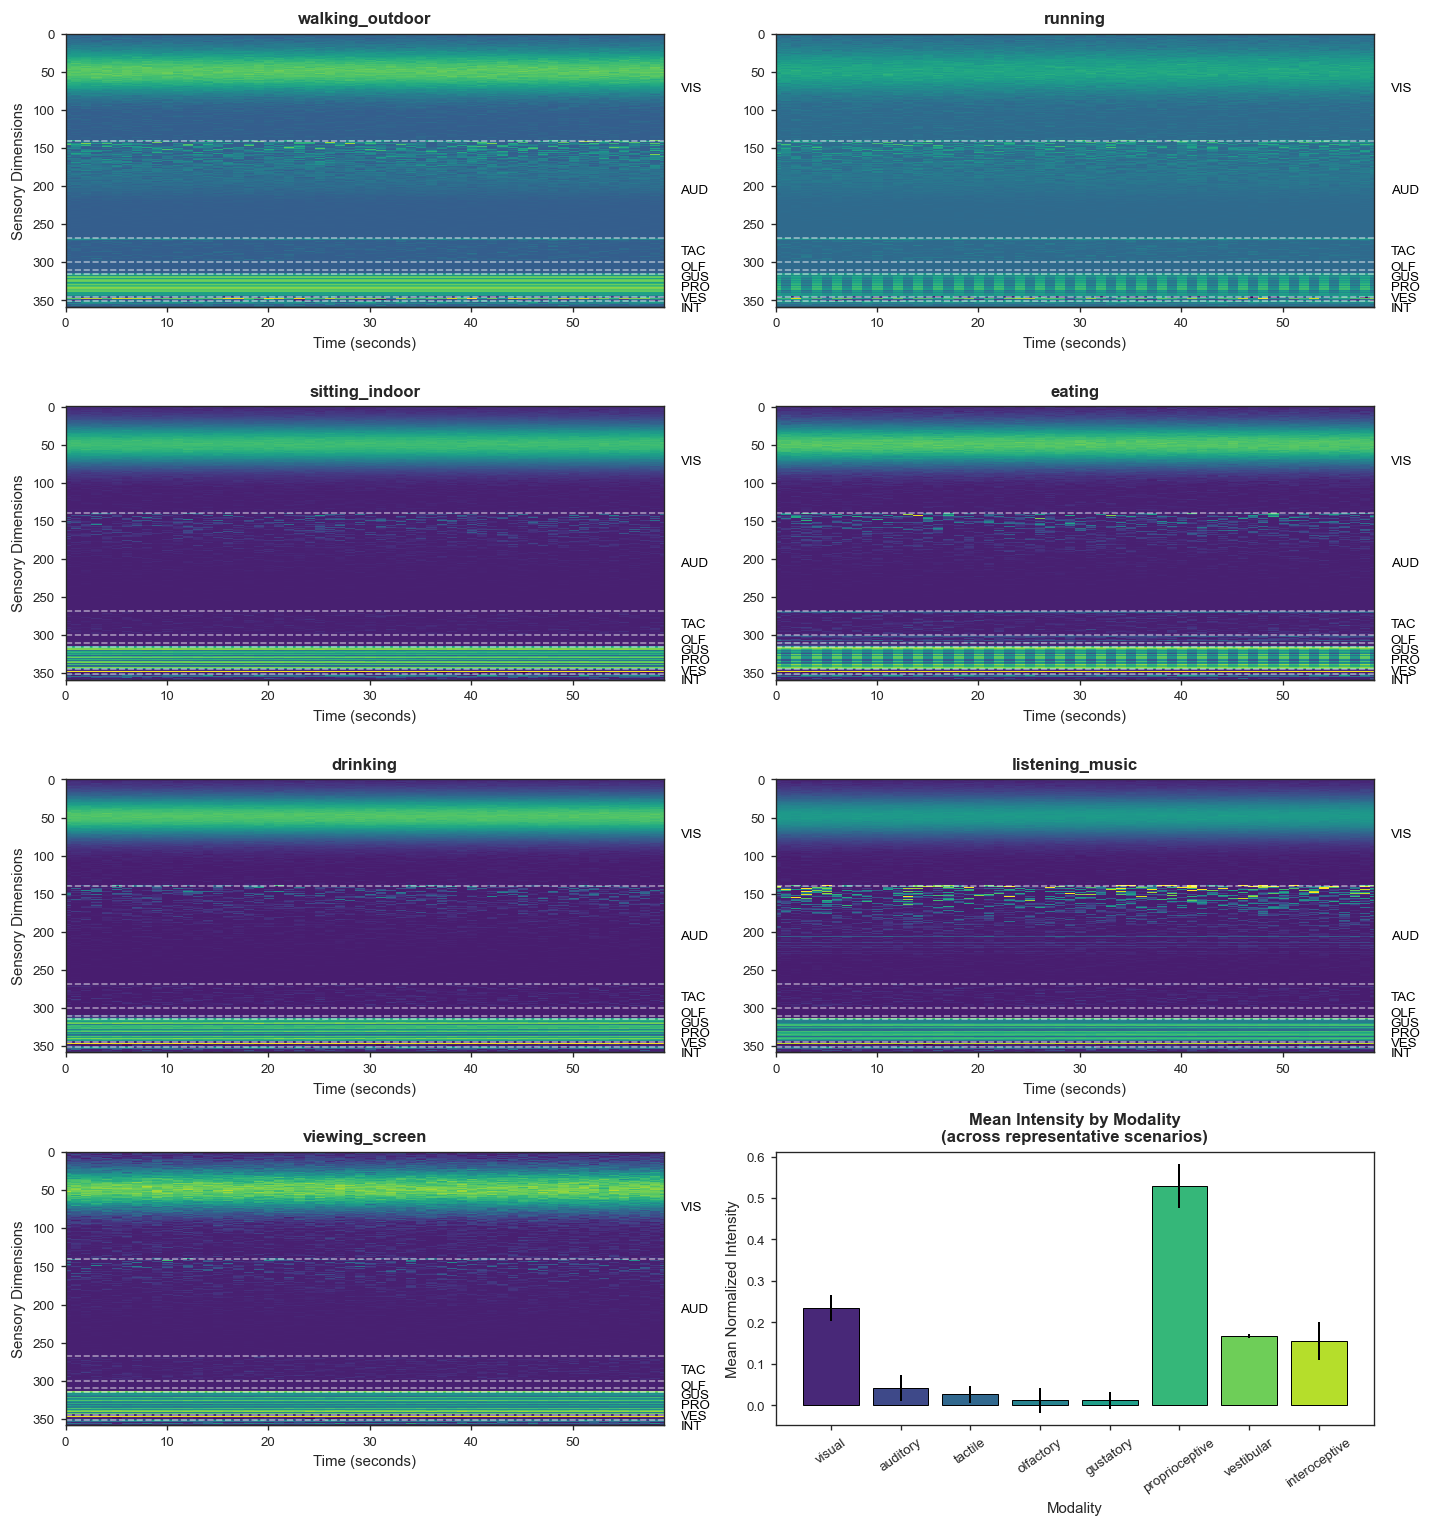

In [11]:
# Visualize one example from each scenario + one summary panel
fig, axes = plt.subplots(4, 2, figsize=(12.0, 12.8))
axes = axes.flatten()

# Keep exactly 7 scenario heatmaps (one slot reserved for summary)
n_heatmaps = min(len(SCENARIOS), 7)

# Get one representative index for each scenario
scenario_examples = {}
for scenario in list(SCENARIOS.keys())[:n_heatmaps]:
    idx = train_labels.index(scenario)
    scenario_examples[scenario] = train_data[idx]

# Modality boundaries and centers
boundaries = [0]
for spec in MODALITY_SPECS.values():
    boundaries.append(boundaries[-1] + spec['dim'])

modality_names = list(MODALITY_SPECS.keys())
modality_labels = [m[:3].upper() for m in modality_names]
modality_centers = np.array([(start + end) / 2 for start, end in zip(boundaries[:-1], boundaries[1:])], dtype=float)

# Create de-overlapped right-side label positions
min_gap = 13.0  # y-axis units
label_positions = modality_centers.copy()
for k in range(1, len(label_positions)):
    if label_positions[k] - label_positions[k - 1] < min_gap:
        label_positions[k] = label_positions[k - 1] + min_gap

y_max = boundaries[-1] - 1
if label_positions[-1] > y_max:
    label_positions[-1] = y_max
    for k in range(len(label_positions) - 2, -1, -1):
        if label_positions[k + 1] - label_positions[k] < min_gap:
            label_positions[k] = label_positions[k + 1] - min_gap

# Plot 7 heatmaps
for i, (scenario_name, example) in enumerate(scenario_examples.items()):
    ax = axes[i]

    # Plot all modalities stacked
    ax.imshow(example.T, aspect='auto', cmap='viridis', interpolation='nearest')

    # Lock x-range to data columns to avoid right-side empty strip
    ax.set_xlim(0, example.shape[0] - 1)

    # Add modality boundaries
    for boundary in boundaries[1:-1]:
        ax.axhline(y=boundary, color='white', linestyle='--', linewidth=1, alpha=0.5)

    # Put modality labels outside the heatmap on the right side
    ax_right = ax.twinx()
    ax_right.set_ylim(ax.get_ylim())
    ax_right.set_yticks(label_positions)
    ax_right.set_yticklabels(modality_labels)
    ax_right.tick_params(axis='y', length=0, pad=10, colors='black')
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['left'].set_visible(False)

    # Disable seaborn whitegrid for this figure
    ax.grid(False)
    ax_right.grid(False)

    ax.set_title(f"{scenario_name}")
    ax.set_xlabel('Time (seconds)')

    # Remove duplicated y-axis labels for right-column heatmaps: figures 2, 4, 6.
    if i in (1, 3, 5):
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Sensory Dimensions')

# Summary panel in bottom-right
summary_ax = axes[7]
scenario_arrays = list(scenario_examples.values())
scenario_profiles = {}
for modality, (start, end) in zip(modality_names, zip(boundaries[:-1], boundaries[1:])):
    mean_intensities = [arr[:, start:end].mean() for arr in scenario_arrays]
    scenario_profiles[modality] = (np.mean(mean_intensities), np.std(mean_intensities))

modality_means = [scenario_profiles[m][0] for m in modality_names]
std_intensities = [scenario_profiles[m][1] for m in modality_names]

bar_colors = sns.color_palette('viridis', n_colors=len(modality_names))
summary_ax.bar(
    modality_names,
    modality_means,
    yerr=std_intensities,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.6
)
summary_ax.set_title('Mean Intensity by Modality\n(across representative scenarios)')
summary_ax.set_ylabel('Mean Normalized Intensity')
summary_ax.set_xlabel('Modality')
summary_ax.tick_params(axis='x', rotation=35)
summary_ax.grid(False)

plt.tight_layout()
plt.savefig(output_dir / 'example_scenarios.png', dpi=300, bbox_inches='tight')
print(f"\nVisualization saved to: {output_dir / 'example_scenarios.png'}")
plt.show()

### Publication-Optimized Visualization (Paper-Ready)


Publication-optimized visualization saved to: data/example_scenarios_publication.png


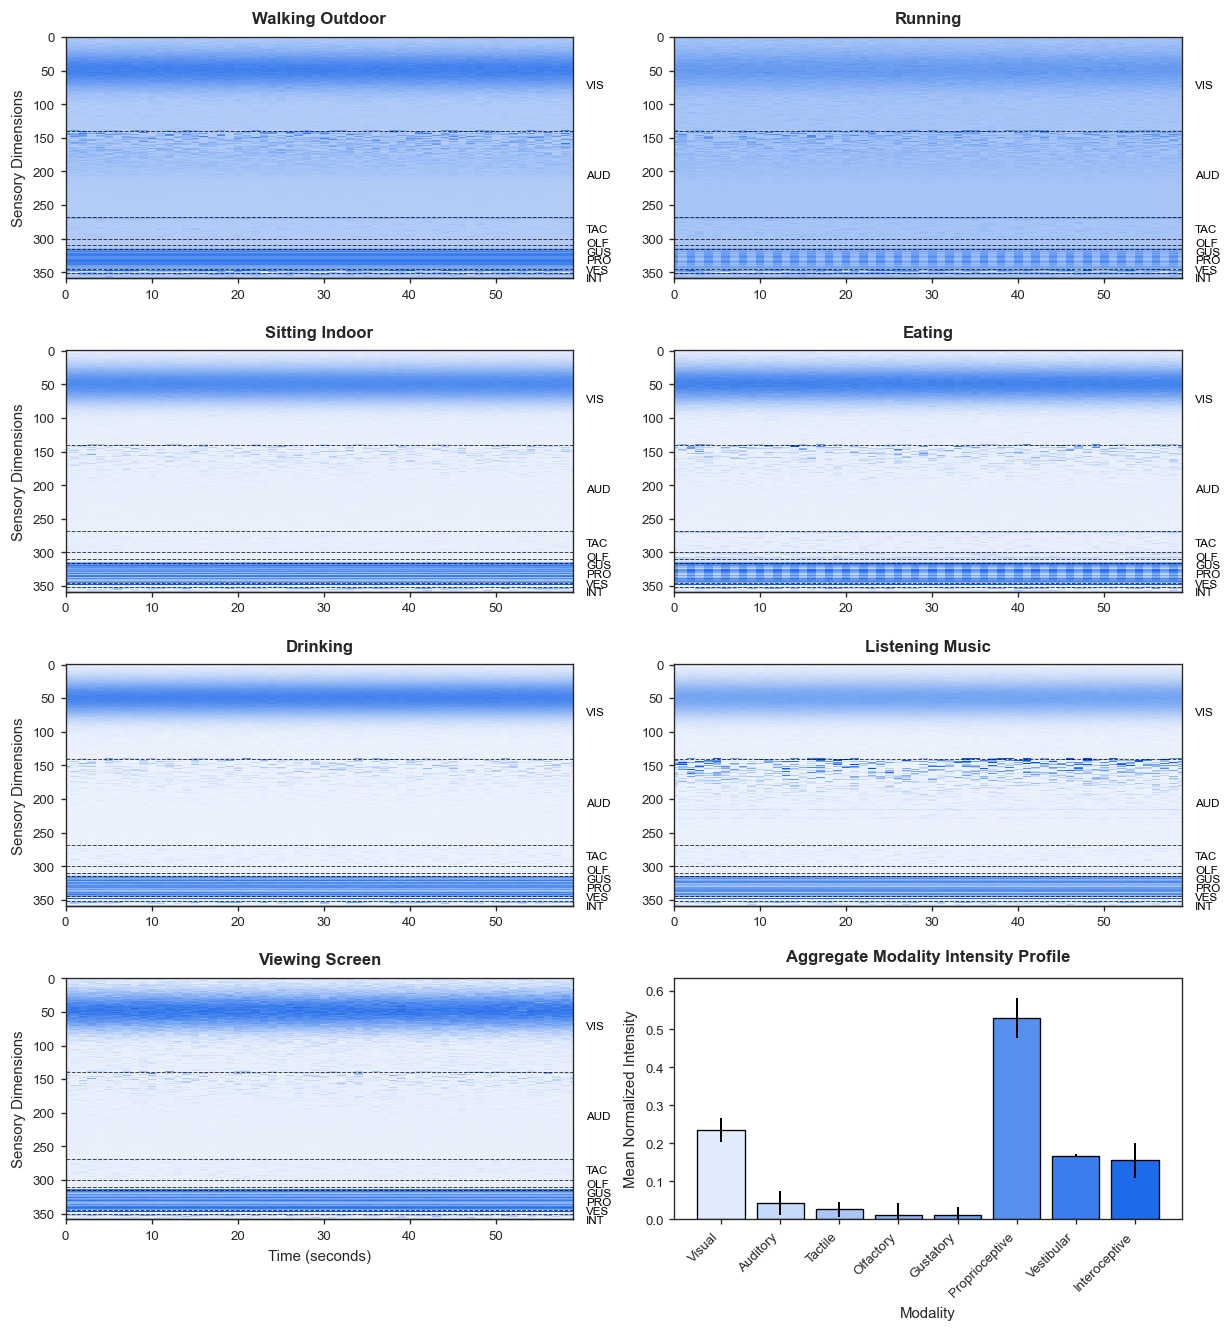

In [13]:
# Publication-optimized version with larger fonts, better spacing, and improved readability
fig, axes = plt.subplots(4, 2, figsize=(12.0, 12.8), 
                         gridspec_kw={'hspace': 0.3, 'wspace': 0.2})
axes = axes.flatten()

# Use same scenario examples from above
n_heatmaps = min(len(SCENARIOS), 7)

# Plot 7 heatmaps with publication-optimized formatting
for i, (scenario_name, example) in enumerate(scenario_examples.items()):
    ax = axes[i]

    # Plot all modalities stacked with project colormap (white -> sky blue)
    im = ax.imshow(example.T, aspect='auto', cmap=WHITE_SKY_CMAP, interpolation='nearest')

    # Lock x-range to data columns
    ax.set_xlim(0, example.shape[0] - 1)

    # Add modality boundaries with better visibility
    for boundary in boundaries[1:-1]:
        ax.axhline(y=boundary, color='black', linestyle='--', linewidth=0.6, alpha=0.7)

    # Enhanced title formatting
    ax.set_title(f"{scenario_name.replace('_', ' ').title()}", pad=8)

    # Put modality labels outside the heatmap on the right side
    ax_right = ax.twinx()
    ax_right.set_ylim(ax.get_ylim())
    ax_right.set_yticks(label_positions)
    ax_right.set_yticklabels(modality_labels, fontsize=7, color='black')
    ax_right.tick_params(axis='y', length=0, pad=8, colors='black')
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['left'].set_visible(False)

    # Disable grid
    ax.grid(False)
    ax_right.grid(False)

    # X-label only on bottom row heatmap panel
    if i == 6:
        ax.set_xlabel('Time (seconds)')
    else:
        ax.set_xlabel('')

    # Conditional y-axis labeling for right-column heatmaps
    if i in (1, 3, 5):
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Sensory Dimensions')

# Enhanced summary panel with better visual formatting
summary_ax = axes[7]
modality_means = [scenario_profiles[m][0] for m in modality_names]
std_intensities = [scenario_profiles[m][1] for m in modality_names]
n_mod = len(modality_names)

# Use project color palette (blue -> gray ramp for 8 modalities)
bar_colors = [WHITE_SKY_CMAP(x) for x in np.linspace(0.12, 0.88, n_mod)]
summary_ax.bar(
    range(len(modality_names)),
    modality_means,
    yerr=std_intensities,
    color=bar_colors,
    edgecolor='black',
    #linewidth=0.5,
    #capsize=3,
    #error_kw={'linewidth': 0.5}
)

summary_ax.set_title('Aggregate Modality Intensity Profile', pad=10)
summary_ax.set_ylabel('Mean Normalized Intensity')
summary_ax.set_xlabel('Modality')
summary_ax.set_xticks(range(len(modality_names)))
summary_ax.set_xticklabels([m.title() for m in modality_names], rotation=45, ha='right')
summary_ax.set_ylim(0, max(modality_means) * 1.2)
summary_ax.grid(False)
summary_ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(output_dir / 'example_scenarios_publication.png', dpi=300, bbox_inches='tight')
print(f"\nPublication-optimized visualization saved to: {output_dir / 'example_scenarios_publication.png'}")
plt.show()


### Publication Figure — Compact Style (modality labels on y-axis, shared colorbar)


Compact figure saved to: data/example_scenarios_compact.png
Color scale from data: vmin=-0.1508, vmax=0.6505


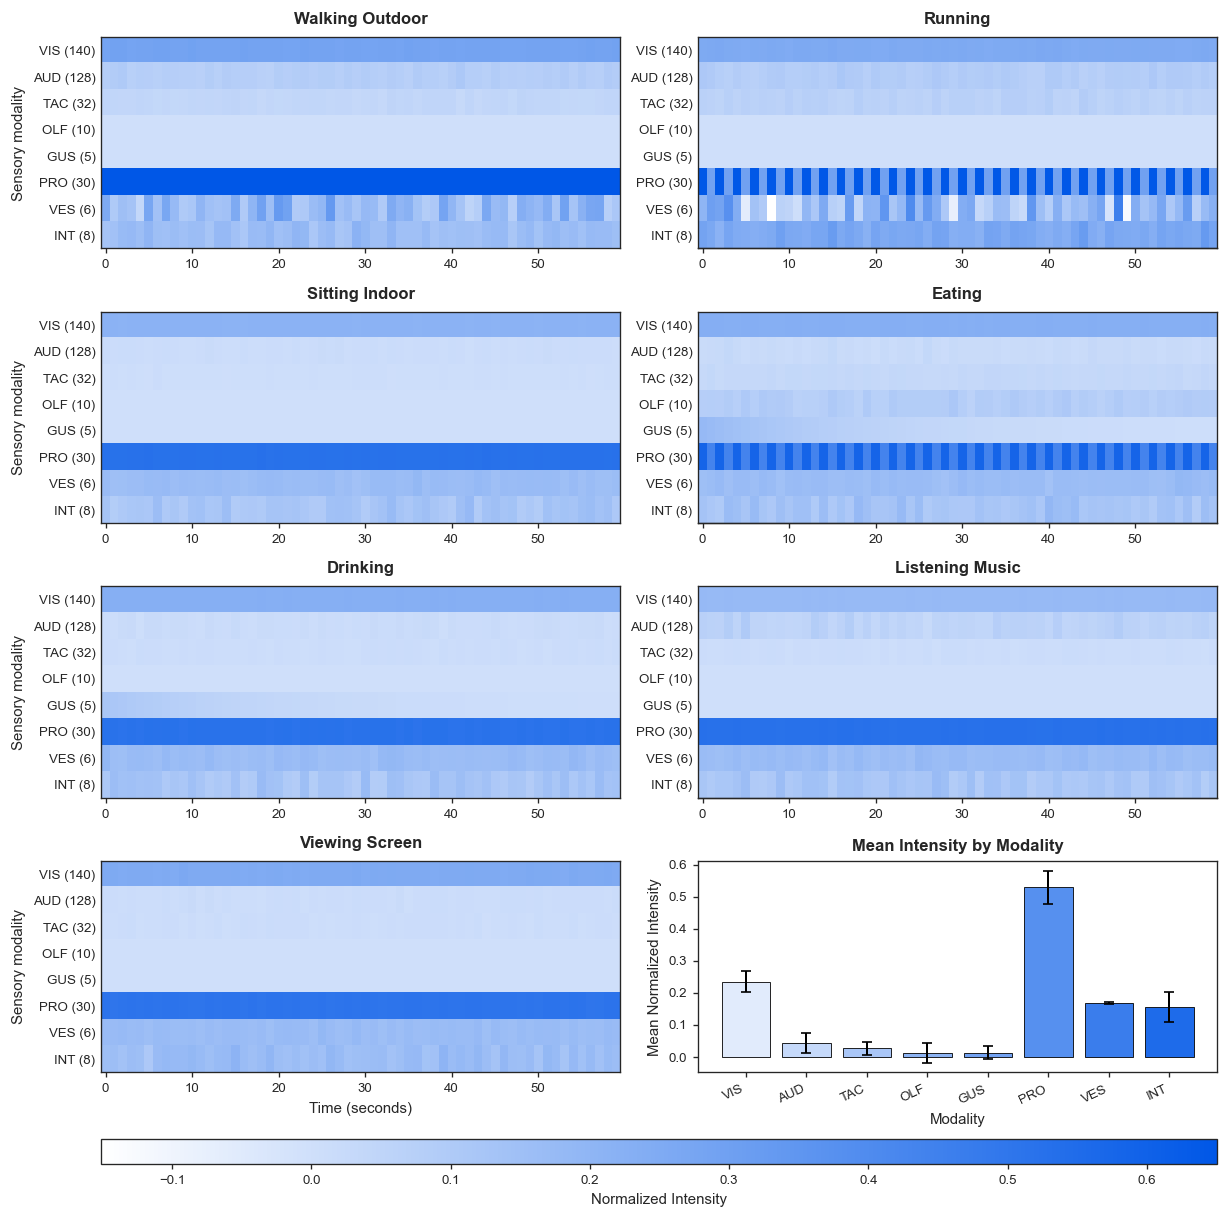

In [14]:

# Compact publication figure — equal-height bands via per-modality mean.
# Each modality is collapsed to its mean across dimensions → shape (T,).
# Stacking gives an (n_mod × T) matrix where every row is identical height.
n_mod = len(modality_names)

# Precompute modality start indices
mod_starts = [0]
for spec in MODALITY_SPECS.values():
    mod_starts.append(mod_starts[-1] + spec['dim'])

# Y-axis tick labels: "VIS (140)", "AUD (128)", …
modality_ytick_labels = [
    f"{m[:3].upper()} ({MODALITY_SPECS[m]['dim']})" for m in modality_names
]

scenario_items = list(scenario_examples.items())  # 7 scenarios

# Build all mean-collapsed matrices once and use global data min/max for contrast.
scenario_mean_matrices = []
for _, example in scenario_items:
    mean_matrix = np.stack(
        [example[:, mod_starts[k]:mod_starts[k + 1]].mean(axis=1)
         for k in range(n_mod)],
        axis=0
    )
    scenario_mean_matrices.append(mean_matrix)

all_values = np.concatenate([m.ravel() for m in scenario_mean_matrices])
vmin_g = float(all_values.min())
vmax_g = float(all_values.max())
if np.isclose(vmin_g, vmax_g):
    vmax_g = vmin_g + 1e-6

fig, axes = plt.subplots(4, 2, figsize=(12.0, 11.2), 
                         gridspec_kw={'hspace': 0.30, 'wspace': 0.15})
axes = axes.flatten()

im_ref = None  # keep one AxesImage for the shared colorbar

for panel_idx in range(7):
    scenario_name, _ = scenario_items[panel_idx]
    ax = axes[panel_idx]
    mean_matrix = scenario_mean_matrices[panel_idx]

    im = ax.imshow(
        mean_matrix, aspect='auto', cmap=WHITE_SKY_CMAP,
        interpolation='nearest', vmin=vmin_g, vmax=vmax_g
    )
    if im_ref is None:
        im_ref = im

    ax.set_xlim(-0.5, mean_matrix.shape[1] - 0.5)

    row, col = divmod(panel_idx, 2)

    # Y-axis: left column labels on the left axis; right column labels on the right axis.
    ax.set_yticks(range(n_mod))
    if col == 0:
        ax.set_yticklabels(modality_ytick_labels)
        ax.set_ylabel('Sensory modality')
    else:
        ax.set_yticklabels(modality_ytick_labels)
        ax.set_ylabel('')
        ax_right = ax.twinx()
        ax_right.set_ylim(ax.get_ylim())
        ax_right.set_yticks(range(n_mod))
        ax_right.set_yticklabels([])
        ax_right.tick_params(axis='y', length=0, pad=8, colors='black')
        ax_right.spines['right'].set_visible(False)
        ax_right.spines['top'].set_visible(False)
        ax_right.spines['left'].set_visible(False)
        ax_right.grid(False)

    ax.tick_params(axis='y', length=0)
    ax.set_title(scenario_name.replace('_', ' ').title(), pad=8)

    # X-label only on bottom row panels
    if row == 3:
        ax.set_xlabel('Time (seconds)')
    else:
        ax.set_xlabel('')

    ax.grid(False)

# Summary bar chart in bottom-right with colors sampled from the same cmap
summary_ax = axes[7]
bar_colors = [WHITE_SKY_CMAP(x) for x in np.linspace(0.12, 0.88, n_mod)]
summary_ax.bar(
    range(n_mod), modality_means, yerr=std_intensities,
    color=bar_colors, edgecolor='black', linewidth=0.5, capsize=3
)
summary_ax.set_title('Mean Intensity by Modality', pad=6)
summary_ax.set_ylabel('Mean Normalized Intensity')
summary_ax.set_xlabel('Modality')
summary_ax.set_xticks(range(n_mod))
summary_ax.set_xticklabels([m[:3].upper() for m in modality_names], rotation=25, ha='right')
summary_ax.grid(False)

# Shared horizontal colorbar matched exactly to subplot block width,
# and positioned directly under the subplot block to avoid a large gap.
plt.tight_layout()
fig.canvas.draw()
plot_axes = axes.tolist()
left = min(a.get_position().x0 for a in plot_axes)
right = max(a.get_position().x1 for a in plot_axes)
bottom = min(a.get_position().y0 for a in plot_axes)

cbar_height = 0.018
cbar_pad = 0.05
cbar_y = max(0.005, bottom - cbar_pad - cbar_height)

cbar_ax = fig.add_axes([left, cbar_y, right - left, cbar_height])
cb = fig.colorbar(im_ref, cax=cbar_ax, orientation='horizontal')
cb.set_label('Normalized Intensity')

plt.savefig(output_dir / 'example_scenarios_compact.png', dpi=300, bbox_inches='tight')
print(f"\nCompact figure saved to: {output_dir / 'example_scenarios_compact.png'}")
print(f"Color scale from data: vmin={vmin_g:.4f}, vmax={vmax_g:.4f}")
plt.show()


## 8. Generate Summary Statistics

In [15]:
# Compute statistics per modality
stats = {}

for i, (modality, spec) in enumerate(MODALITY_SPECS.items()):
    start = boundaries[i]
    end = boundaries[i + 1]
    
    modality_data = train_data[:, :, start:end].reshape(-1, spec['dim'])
    
    stats[modality] = {
        'mean': float(modality_data.mean()),
        'std': float(modality_data.std()),
        'min': float(modality_data.min()),
        'max': float(modality_data.max()),
        'median': float(np.median(modality_data))
    }

# Print summary
print("\n" + "=" * 60)
print("DATASET SUMMARY STATISTICS")
print("=" * 60)
for modality, stat in stats.items():
    print(f"\n{modality.upper()} ({MODALITY_SPECS[modality]['dim']}-dim):")
    print(f"  Mean: {stat['mean']:.4f}")
    print(f"  Std:  {stat['std']:.4f}")
    print(f"  Range: [{stat['min']:.4f}, {stat['max']:.4f}]")

# Save stats
with open(output_dir / 'dataset_statistics.json', 'w') as f:
    json.dump(stats, f, indent=2)

print(f"\nStatistics saved to: {output_dir / 'dataset_statistics.json'}")


DATASET SUMMARY STATISTICS

VISUAL (140-dim):
  Mean: 0.2346
  Std:  0.2368
  Range: [0.0000, 0.9365]

AUDITORY (128-dim):
  Mean: 0.0421
  Std:  0.1009
  Range: [0.0000, 1.0000]

TACTILE (32-dim):
  Mean: 0.0264
  Std:  0.0621
  Range: [0.0000, 0.7508]

OLFACTORY (10-dim):
  Mean: 0.0120
  Std:  0.0374
  Range: [0.0000, 0.5175]

GUSTATORY (5-dim):
  Mean: 0.0128
  Std:  0.0352
  Range: [0.0000, 0.6717]

PROPRIOCEPTIVE (30-dim):
  Mean: 0.5177
  Std:  0.1739
  Range: [0.0000, 1.0000]

VESTIBULAR (6-dim):
  Mean: 0.1665
  Std:  0.3571
  Range: [-1.6813, 2.3654]

INTEROCEPTIVE (8-dim):
  Mean: 0.1567
  Std:  0.1575
  Range: [0.0000, 0.7176]

Statistics saved to: data/dataset_statistics.json


## 9. Scenario Distribution Analysis


Scenario distribution plot saved to: data/scenario_distribution.png


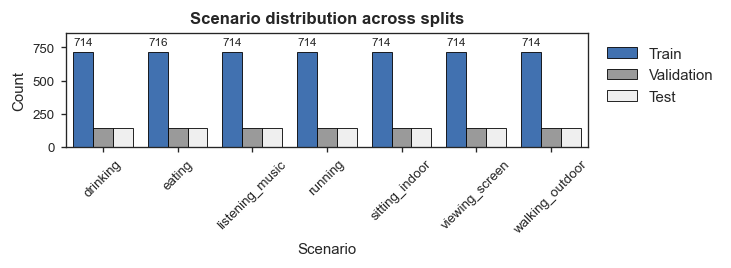


Dataset generation complete!

All files saved in: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/data


In [16]:

# Count scenario distribution
from collections import Counter

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
test_counts = Counter(test_labels)

# prepare data for grouped bar chart so differences are easier to compare
scenarios = sorted(SCENARIOS.keys())
data = {'scenario': [], 'split': [], 'count': []}
for s in scenarios:
    data['scenario'].append(s); data['split'].append('Train'); data['count'].append(train_counts[s])
    data['scenario'].append(s); data['split'].append('Validation'); data['count'].append(val_counts[s])
    data['scenario'].append(s); data['split'].append('Test'); data['count'].append(test_counts[s])

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=fw(2.06))
sns.barplot(data=df, x='scenario', y='count', hue='split', ax=ax,
            palette=BLUE_GRAY_RAMP[1::2],
            edgecolor='black', linewidth=0.5)
ax.set_xlabel('Scenario')
ax.set_ylabel('Count')
ax.set_title('Scenario distribution across splits')
ax.tick_params(axis='x', rotation=45)
ax.grid(False)

# Annotate only tall bars (Train) to avoid collision on the small Val/Test bars.
# Also guard against seaborn's zero-height phantom patches.
y_max = ax.get_ylim()[1]
for p in ax.patches:
    height = p.get_height()
    if height < 200:          # skip Val / Test bars and empty patches
        continue
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 3), textcoords='offset points',
        fontsize=7,
    )

# Give enough top headroom so annotations don't overlap the title
ax.set_ylim(0, y_max * 1.14)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(output_dir / 'scenario_distribution.png', dpi=300, bbox_inches='tight')
print(f"\nScenario distribution plot saved to: {output_dir / 'scenario_distribution.png'}")
plt.show()

print("\nDataset generation complete!")
print(f"\nAll files saved in: {output_dir.absolute()}")
